Dzelila Hamzic


## Final Assignment 

 For the obligatory assignment, you will use what you learned so far. The task is to code the solutions for the exercises, as well as edit the markdown cells underneath them, reporting  your choices, findings, and interpretations.

## A random protein dataset
You will work with a new randomly generated dataset called `mice_dataset.csv`. There is a cell with the code to set up the dataset, but be careful to only run that code once, otherwise you will overwrite your previous dataset, and your conclusions and results might not be reliable anymore.

## The goal

The evaluation __is not__ related to the results of your analysis. We are not looking for p-values or coefficients.
We will evaluate if: 
1. you can deliver a notebook that can run without `error`. 
2. you are applying the right tools. 
3. you can report your reasoning clearly.

## How to deliver
On GitHub, create a repository and invite us (HenriChap, JM-Godoy, hbarsnes) to contribute, so that we can evaluate.
Remember to set the visibility of your repo to `private` and write a `README.md` file.

---
### Setting up the exercise (generating random data)

Run the code below __only once__ to start your assignment.

Suggestion: comment out the code using `#` to make sure it won't run again.


In [1]:
#from random_dataset_generator import save_random_mice_dataset

#df = save_random_mice_dataset()

### Loading resources needed
Load all packages and modules needed. A nice way to keep track of the packages is adding them app along you are using them.

In [2]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf

# organising things
if not pathlib.Path("figures").exists():
    pathlib.Path("figures").mkdir()
    
# customising visualisation
sns.set_theme(style = "whitegrid", context = "notebook")

Your notes:

In [ ]:
# using the "if not pathlib.Path" to create a figures/ folder for saving plots, and customization so that a default look is set for every seaborn plot in the notebook.

### Reading the file

Load the `mice_dataset.csv`.

In [5]:
# storing mice_dataset.csv into a file_path
file_path = pathlib.Path("data") / "mice_dataset.csv"

# checking if my file_path actually exists (the answer was true = yes)
print(file_path.exists())

# loading the data into a dataframe 
df = pd.read_csv(file_path)

True


Your notes:

In [ ]:
# since mice_dataset.csv is loaded into a dataframe i will continue to use "df" to refer to it.

### Describe the data 

In [10]:
print(df.shape) # tells me how big the table is
print(df.info()) # tells me column names, data types and missing values
df.head() # shows me what the rows look like

(11, 140)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Columns: 140 entries, 0 to 139
dtypes: object(140)
memory usage: 12.2+ KB
None


,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
0,Mice001,Mice002,Mice003,Mice004,Mice005,Mice006,Mice007,Mice008,Mice009,Mice010,...,Mice131,Mice132,Mice133,Mice134,Mice135,Mice136,Mice137,Mice138,Mice139,Mice140
1,F,F,F,M,F,M,F,F,M,F,...,M,M,F,M,F,F,F,M,M,M
2,Treatment,Control,Treatment,Treatment,Control,Treatment,Control,Treatment,Control,Control,...,Control,Control,Treatment,Treatment,Control,Control,Control,Treatment,Treatment,Treatment
3,19.99692738875441,20.260557355001865,22.576815369037433,27.9143785257877,19.122689936385253,25.58510243891393,16.262171578598362,24.035953693058687,31.783499155737253,17.593204880907074,...,26.84133029281872,30.2268405898621,20.069983727512323,28.242243895369864,15.52472657878311,23.402024095760872,22.035050145508524,23.625594443950344,24.85352763664962,27.360315824462816
4,26,32,27,34,34,30,29,34,34,26,...,31,28,26,33,32,29,30,29,30,26


Your notes:

In [ ]:
# This file was read as 11 rows and 140 columns. All are of dtype object (stored as text) where columns are from 0 to 139.
# Each column is one mouse and each row is a variable: mouse ID, sex, treatment group and then measurments. 

### Inspect and clean your data 

In [30]:
df = pd.read_csv(file_path)
df = df.T

# finding out what each variable is
# print(open("random_dataset_generator.py").read())

# renaming columns in the table
df = df.rename(columns={0: "mouse_id",
                       1: "sex",
                       2: "treatment",
                       3: "weight_g",
                       4: "age_weeks",
                       5: "protein1",
                       6: "protein2",
                       7: "protein3",
                       8: "protein4",
                       9: "protein5",
                       10: "protein6"})
print(df.shape)

# setting the types
for col in ["sex", "treatment"]:
    df[col] = df[col].astype("category")

for col in ["weight_g", "age_weeks", "protein1", "protein2",
            "protein3", "protein4", "protein5", "protein6"]:
    df[col] = df[col].astype(float)

df.info()
df.head()

# counting the missing values
df.isnull().sum()

# dropping the column and the few incomplete rows to clean the data
df = df.drop(columns="protein6")
df_clean = df.dropna()
print(df_clean.shape)

# saving the data
df_clean.to_csv("data/mice_clean.csv", index=False)

(140, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 139
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   mouse_id   140 non-null    object  
 1   sex        137 non-null    category
 2   treatment  137 non-null    category
 3   weight_g   137 non-null    float64 
 4   age_weeks  140 non-null    float64 
 5   protein1   138 non-null    float64 
 6   protein2   137 non-null    float64 
 7   protein3   137 non-null    float64 
 8   protein4   138 non-null    float64 
 9   protein5   137 non-null    float64 
 10  protein6   28 non-null     float64 
dtypes: category(2), float64(8), object(1)
memory usage: 11.5+ KB
(137, 10)


Your notes:

In [ ]:
# Since the file was saved as one column per mouse and one row per variable, i flipped it with .T so each row is one mouse and each column is one variable which makes the table much more clean.

# I identyfied the column names, which showed me the order and meaning of each variable. And to make it more understandable i renamed the columns.

# All values were read as text, therefore sex and treatment were set as category because they are grouping variables. 
# While the measurments were converted to float so they can be used in calculations and plots.

# When running the "counting missing values", i saw that protein6 was missing in 112 of 140 mice, which means it was measured on a very few mice.
# Since 28 observations is too little for reliable analysis i dropped the column and removed rows with remaining missing values.(Ended up with 137 mice and 10 columns)

# Saved the new clean dataset in data/mice_clean.csv and added the index=false so the row numbers dont get saved since they are not data.

### Understand the mice population.
Use table and plots to understand how is your data distributed.

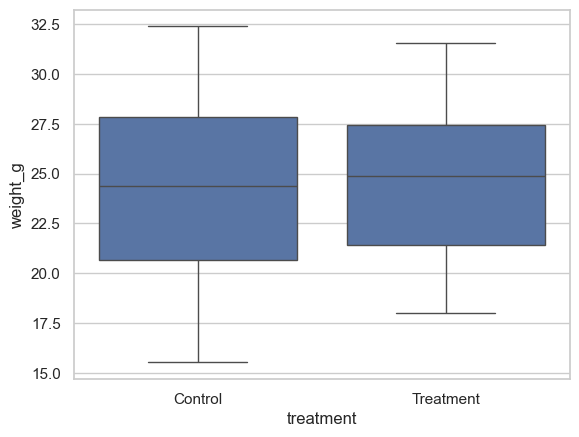

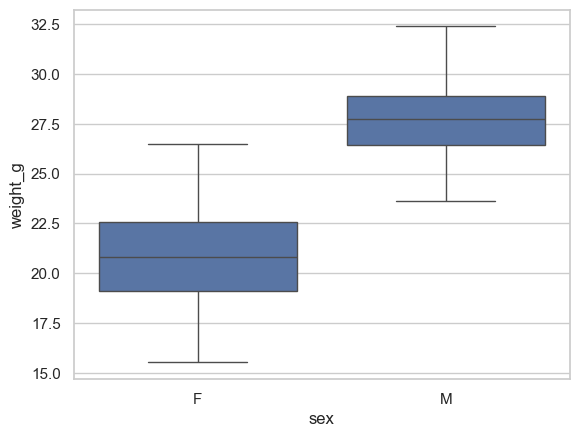

In [38]:
# programming a table for the numeric variables
df_clean.describe()

# for the categorical ones
df_clean["sex"].value_counts() # the control and treatment groups are balanced
df_clean["treatment"].value_counts() # the control and treatment groups are balanced

# plotting a boxplot to see how it distributes my data 
sns.boxplot(data = df_clean, x = "treatment", y = "weight_g")
plt.show()

# with sex and weight
sns.boxplot(data = df_clean, x = "sex", y = "weight_g")
plt.show()

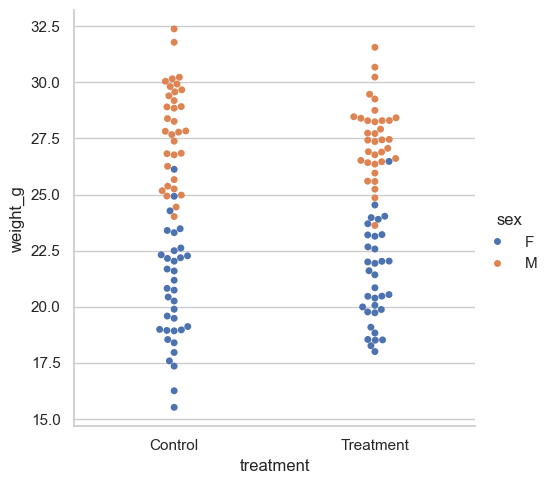

In [44]:
# with swarmplot
sns.catplot(data = df_clean, kind = "swarm", x = "treatment", y = "weight_g", hue = "sex")
plt.show()

Your notes:

In [ ]:
# When looking at weight and treatment we can see that the boxes almost overlap, which means that weight does not differ a lot between control group and treatment group.

# However, weight does differ between sexes which is shown in the second boxplots.

# Then i ran a swarmplot which showed me that male mice had a higher weight both in the control and treatment group.
# this explains the wide spread in the treatment boxplot.

### Explore the relationship between the proteins

Plot data to give you information about possible relationships between proteins.

In [45]:
numeric_cols = df_clean.select_dtypes(float).columns.tolist()
print(numeric_cols)

# checking correlations
corr = df_clean[numeric_cols].corr()
print("Correlation matrix (rounded)")
print(corr.round(2))

['weight_g', 'age_weeks', 'protein1', 'protein2', 'protein3', 'protein4', 'protein5']
Correlation matrix (rounded)
           weight_g  age_weeks  protein1  protein2  protein3  protein4  \
weight_g       1.00      -0.05      0.60     -0.01      0.06     -0.02   
age_weeks     -0.05       1.00      0.04      0.73      0.03     -0.12   
protein1       0.60       0.04      1.00      0.06      0.05      0.07   
protein2      -0.01       0.73      0.06      1.00     -0.02     -0.14   
protein3       0.06       0.03      0.05     -0.02      1.00      0.07   
protein4      -0.02      -0.12      0.07     -0.14      0.07      1.00   
protein5       0.52       0.34      0.88      0.48      0.02     -0.00   

           protein5  
weight_g       0.52  
age_weeks      0.34  
protein1       0.88  
protein2       0.48  
protein3       0.02  
protein4      -0.00  
protein5       1.00  


<AxesSubplot: >

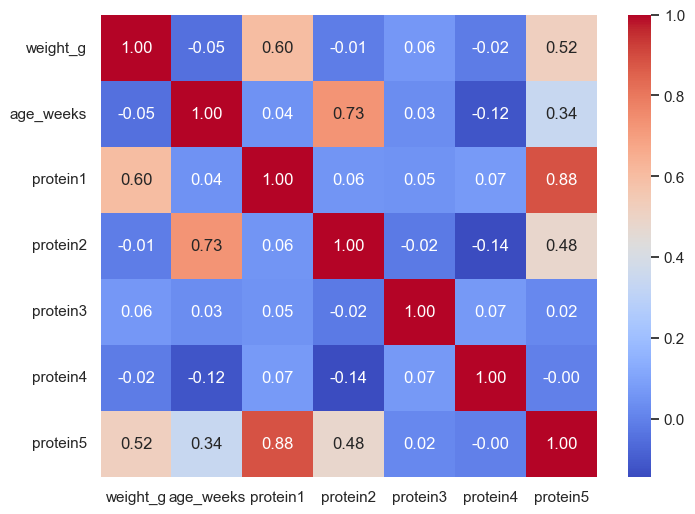

In [46]:
# making a heatmap to visualise it better
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", cbar = True)

Your notes:

In [ ]:
# After making a heatmap i could easily see which proteins had the best positive correlation. Those were protein1 and protein5 (0.88)

### Choose two proteins and explore the relationship between them.

After plotting the data, use linear regression to understand the relationship of those two proteins.

<AxesSubplot: xlabel='protein1', ylabel='protein5'>

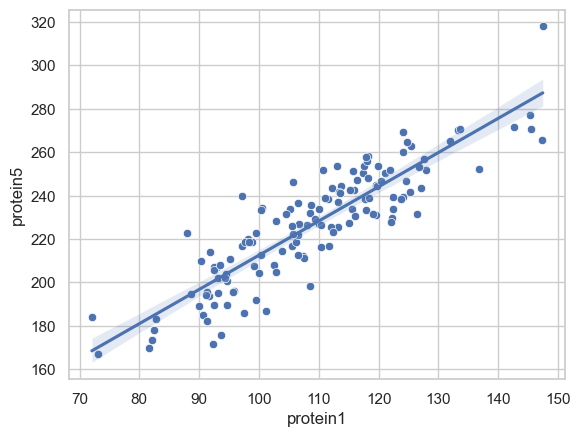

In [50]:
# Choosing protein1 and protein5 since they had the best positive correlation
# making a scatterplot first
sns.scatterplot(data = df_clean, x = "protein1", y = "protein5")

# linear regression
sns.regplot(data = df_clean, x = "protein1", y = "protein5", scatter = False)

Your notes:

In [ ]:
# After a linear regression line i saw that the correlation between protein1 and 5 was positive, but the shadow line around the regression line was a little wider in the top and bottom, which means that the plots are more different here.
# The line is also sloping up which means that protein1 and protein5 increase together.
# The points sit tightly in the middle which means the relationship is strong between the proteins.

### Choose a protein and test if there is a difference between any non-protein variable

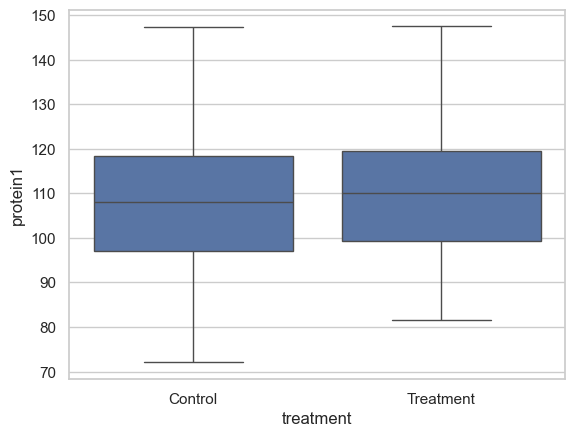

t = -0.6402172820116484
p = 0.5231164649324846


In [51]:
# making a boxplot to visualise the difference between treatment and protein1
sns.boxplot(data = df_clean, x = "treatment", y = "protein1")
plt.show()

# testing if protein1 level differs between the mice that got the treatment and those that did not
control = df_clean[df_clean["treatment"] == "Control"]["protein1"]
treated = df_clean[df_clean["treatment"] == "Treatment"]["protein1"]

t, p = stats.ttest_ind(control, treated)
print("t =", t)
print("p =", p)

Your notes:

In [ ]:
# By looking at the boxes i can see that they overlap quite a bit. The p-value confirms this with it being 0.52 (way above 0.05)
# This means that there is no significant difference in protein1 between the two groups.